In [33]:
%reload_ext autoreload
%autoreload 2

[autoreload of probjax.nn failed: Traceback (most recent call last):
  File "/root/miniconda3/envs/probjax_new/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "/root/miniconda3/envs/probjax_new/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 475, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "/root/miniconda3/envs/probjax_new/lib/python3.12/importlib/__init__.py", line 131, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 866, in _exec
  File "<frozen importlib._bootstrap_external>", line 995, in exec_module
  File "<frozen importlib._bootstrap>", line 488, in _call_with_frames_removed
  File "/mnt/c/Users/manug/OneDrive/Uni/PHD/probjax/probjax/nn/__init__.py", line 20, in <module>
    from probjax.nn.loss_fn import (
ImportError: cannot import name 'build_time_dependent_denoising_loss' from 'probjax.nn.loss

In [34]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from flax import nnx


from probjax.nn.loss_fn.denoising import build_time_dependent_denoising_loss

from probjax.nn import MLP, GaussianFourierEmbedding
from probjax.nn.nets.diffusion_model import EDM, VE, VP


In [ ]:
d = 1
class BaseModel(nnx.Module, experimental_pytree=True):
    def __init__(self, d, rngs) -> None:
        #self.time_embedding = GaussianFourierEmbedding(1, d, rngs=rngs)
        self.time_embedding = lambda t: jnp.repeat(t, 5, axis=-1)
        self.mlp = MLP([d+5,100,50,d], rngs=rngs)

    def __call__(self, t,x, *args, **kwargs):
        time_embed = self.time_embedding(t)
        inp = jnp.concatenate([time_embed, x], axis=-1)
        output = self.mlp(inp)
        return output

net = BaseModel(1, nnx.Rngs(0))
model = EDM(net)
params = nnx.state(model, nnx.Param)

In [36]:
nnx.display(model)

In [13]:
def mean_fn(t, x):
    return model.scale_fn(t) * x

def std_fn(t, x):
    return model.scale_fn(t) * model.std_fn(t) * jnp.ones_like(x)

denoiser_loss_fn = build_time_dependent_denoising_loss(model, mean_fn=mean_fn, std_fn=std_fn, weight_fn=model.weight_fn)

In [17]:
def loss_fn(params, x, rng):
    rng_times, rng_loss = jax.random.split(rng, 2)
    nnx.update(model, params)
    # logt = jax.random.normal(rng_times, shape=(x.shape[0], 1)) * 1.2 - 1.2
    # t = jnp.exp(logt) + 0.01
    t = jax.random.uniform(rng_times, shape=(x.shape[0], 1)) *1. + 0.01  

    loss = denoiser_loss_fn(params, t, x, rng=rng_loss)
    return jnp.mean(loss)


In [18]:
xs = jax.random.normal(jax.random.PRNGKey(0), shape=(1000, d))

In [19]:
loss_fn(params, xs, jax.random.PRNGKey(1))

Array(0.284, dtype=float32)

In [20]:
from optax import adam
import optax
opt = adam(5e-4)
opt_state = opt.init(params)
@jax.jit
def update(params, opt_state, x, rng):
    loss, grads = jax.value_and_grad(loss_fn)(params, x, rng)
    updates, opt_state = opt.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

In [21]:
key = jax.random.key(0)

In [22]:
losses = []
for i in range(1000):
    l = 0.
    for j in range(10):
        key,key_data, key_loss = jax.random.split(key, 3)
        xs = jax.random.normal(key_data, (100, d))
        params, opt_state, loss = update(params, opt_state, xs,key_loss)
        l += loss
    print(l/10)
    losses.append(l/10)

0.2984363
0.25228432
0.30559763
0.26824793
0.2635779
0.28025928
0.29555514
0.24654403
0.24733733
0.2741221
0.2510396
0.22139636
0.26709437
0.27492607
0.2676227
0.27840072
0.22147098
0.30391786
0.2675462
0.28617188
0.25978288
0.28343004
0.27215067
0.24927126
0.26797894
0.30074126
0.26684383
0.2845615
0.2747676
0.27897918
0.23098846
0.25928006
0.26892063
0.24795249
0.2724759
0.2796666
0.3051004
0.3035434
0.26990375
0.29069528
0.29686663
0.25491297
0.24868374
0.28440675
0.2850462
0.2909393
0.25065583
0.24338304
0.32435402
0.2509875
0.24877444
0.31843984
0.25794944
0.2564456
0.3009362
0.27482054
0.2714873
0.26119396
0.27380326
0.30014527
0.22819705
0.2693691
0.30321687
0.24509263
0.26473776
0.25312603
0.24116996
0.2800053
0.30272955
0.23642321
0.29382735
0.26902747
0.28290328
0.23338671
0.25431386
0.26284266
0.2567349
0.28853497
0.2672433
0.26827607
0.2864145
0.2751387
0.28907642
0.26221663
0.23922765
0.2609795
0.29287854
0.23840646
0.27688166
0.24903373
0.24983636
0.2873755
0.28657407
0.2

KeyboardInterrupt: 

In [23]:
nnx.update(model, params)

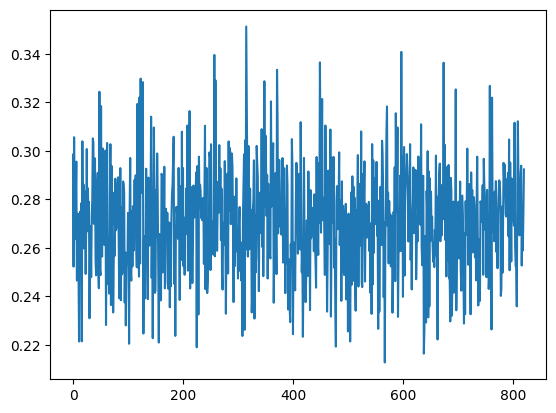

In [24]:
plt.plot(losses)

In [28]:
from probjax.utils.odeint import odeint

def sample(rng, T_end=1.):
    rng_init, rng_sample = jax.random.split(rng)
    eps = jax.random.normal(rng_init, (d,)) * model.marginal_std(T_end)
    ts = jnp.linspace(0.001, T_end, 500)

    def drift(t, x):
        t = jnp.atleast_1d(t)
        f = model.drift(t,x)
        g = model.diffusion(t, x)
        score = model.score(t,x)
        return (f -0.5*g**2*score).reshape(x.shape)

    return odeint(drift, eps,ts[::-1], method="heun")


In [29]:
keys = jax.random.split(key, (10_000,))

In [30]:
xs = jax.vmap(sample)(keys)

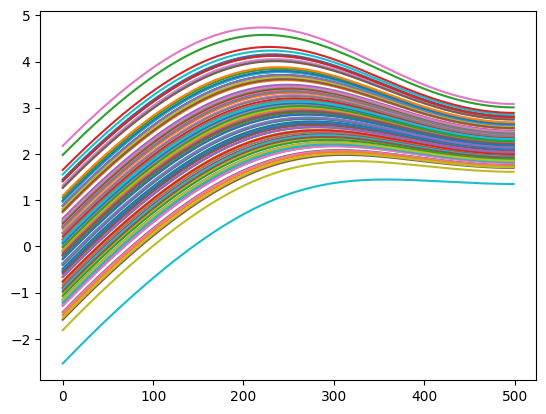

In [31]:
_ = plt.plot(xs[::100,:,0].T)
#plt.ylim(-3,3)

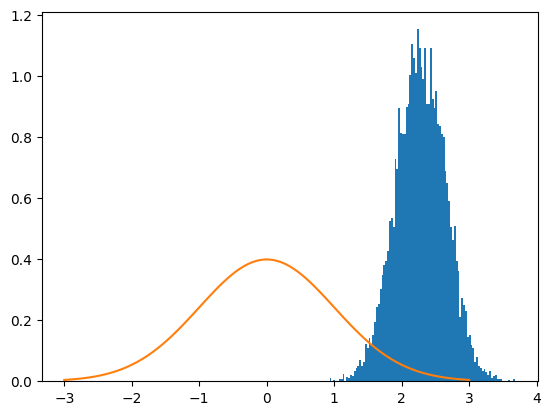

In [32]:
_ = plt.hist(xs[:,-1].flatten(), bins=100, density=True)
_ = plt.plot(jnp.linspace(-3,3,100), jnp.exp(-jnp.linspace(-3,3,100)**2/2)/jnp.sqrt(2*jnp.pi))

In [210]:
from probjax.utils.sdeint import sdeint

def sample(rng, T_end=80.):
    rng_init, rng_sample = jax.random.split(rng)
    eps = jax.random.normal(rng_init, (d,)) * (model.std_fn(T_end) + model.std0)
    ts = jnp.linspace(0.01, T_end, 500)

    def drift(t, x):
        t = jnp.atleast_1d(t)
        f = model.drift(t,x)
        g = model.diffusion(t,x)
        score = model.score(t,x)

        drift_backward = f - g**2 * score
        return drift_backward
    
    def diffusion(t, x):
        t = jnp.atleast_1d(t)
        g = model.diffusion(t,x)
        return g
    
    return sdeint(rng_sample,drift, diffusion, eps, ts[::-1], method="euler_maruyama")
    

    
    

In [211]:
keys = jax.random.split(key, (10_000,))

In [212]:
xs = jax.vmap(sample)(keys)

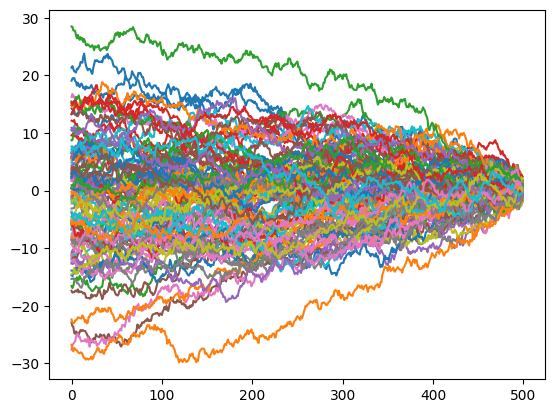

In [213]:
_ = plt.plot(xs[::100,:,0].T)

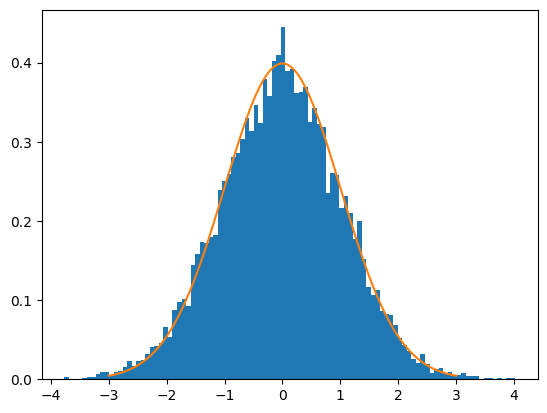

In [214]:
_ = plt.hist(xs[:,-1].flatten(), bins=100, density=True)
_ = plt.plot(jnp.linspace(-3,3,100), jnp.exp(-jnp.linspace(-3,3,100)**2/2)/jnp.sqrt(2*jnp.pi))